# 02 — LLM-as-Policy: Single-Agent Zero-Shot Battery Control

**Phase 2** · MSc Thesis

Supervisor: Dr. Panagiotis Kasnesis | Student: Antonios Bastoulis

---

Evaluates frontier LLMs as zero-shot battery controllers in a **single group-centralized agent setup** over 3 buildings (`TRAINING_BUILDINGS=[0,1,2]`).

One API call per step, 3 actions per call. Aligns with the Phase 3 SFT training shape — at Phase 4 deployment the same agent is instantiated twice (α on B0–2, β on B3–5) but **here we stay single-agent**.

**Rollout window:** 300 hourly steps starting at `t=3624`.

**Providers tested:**

| Provider | Model | API quirks |
|----------|-------|------------|
| Anthropic | `claude-haiku-4-5` | Native client; standard `max_tokens`, `temperature=0`. |
| DeepSeek | `deepseek-chat` (V3) | OpenAI-compat; standard `max_tokens`, `temperature=0`. |
| Kimi | `kimi-k2.5` | OpenAI-compat (Moonshot); **requires `temperature=1`**. |
| OpenAI | `gpt-5.4-nano` | Reasoning-family — uses **`max_completion_tokens`**, **`temperature=1`** only. |

**API keys:** loaded from `.env`. Required: `ANTHROPIC_API_KEY`, `DEEPSEEK_API_KEY`, `KIMI_API_KEY`, `OPENAI_API_KEY`.


## § 0 — Config
> **Change experiment parameters here only.** Nothing else needs editing.

In [1]:
import sys
from pathlib import Path

# ── Make src/ importable ──────────────────────────────────────────────────
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

from src.env import TRAINING_BUILDINGS

# ── Provider list ─────────────────────────────────────────────────────────
PROVIDERS: list[dict] = [
    {"name": "anthropic", "model": "claude-haiku-4-5", "key_env": "ANTHROPIC_API_KEY", "base_url": None},
    {"name": "deepseek",  "model": "deepseek-chat",    "key_env": "DEEPSEEK_API_KEY",  "base_url": "https://api.deepseek.com/v1"},
    {"name": "kimi",      "model": "kimi-k2.5",         "key_env": "KIMI_API_KEY",      "base_url": "https://api.moonshot.ai/v1", "temperature": 1.0},
    {"name": "openai",    "model": "gpt-5.4-nano",      "key_env": "OPENAI_API_KEY",    "base_url": None},
]

# ── Single-agent buildings (Phase 3 design — see CLAUDE.md) ───────────────
BUILDINGS: list[int] = TRAINING_BUILDINGS   # [0, 1, 2]
N_BLDGS:   int        = len(BUILDINGS)

# ── Timeout ──────────────────────────────────────────────────────────────
LLM_TIMEOUT_S: float = 45.0

# ── Experiment window ─────────────────────────────────────────────────────
WEEK_START: int = 3624
WEEK_LEN:   int = 300

# ── Output ───────────────────────────────────────────────────────────────
ARTIFACTS = Path("artifacts").resolve()
ARTIFACTS.mkdir(exist_ok=True)

# ── Sanity print ─────────────────────────────────────────────────────────
import os
print(f"Project root   : {PROJECT_ROOT}")
print(f"Window         : t{WEEK_START}..{WEEK_START + WEEK_LEN - 1} ({WEEK_LEN} steps)")
print(f"Single agent   : buildings {BUILDINGS}  (N_BLDGS={N_BLDGS})")
print(f"Timeout/call   : {LLM_TIMEOUT_S}s")
print(f"\nProviders ({len(PROVIDERS)}):")
for p in PROVIDERS:
    has_key = bool(os.environ.get(p["key_env"], "").strip())
    flag = "OK" if has_key else "MISSING"
    print(f"  [{flag}] {p['name']:10s} model={p['model']:35s} env={p['key_env']}")


Project root   : /Users/antonisbast/projects/eclipse-thesis
Window         : t3624..3923 (300 steps)
Agent α        : buildings [0, 1, 2]
Agent β        : buildings [3, 4, 5]
Timeout/call   : 45.0s

Providers (4):
  [✓] anthropic  model=claude-haiku-4-5                    env=ANTHROPIC_API_KEY
  [✓] deepseek   model=deepseek-chat                       env=DEEPSEEK_API_KEY
  [✓] kimi       model=kimi-k2.5                           env=KIMI_API_KEY
  [✓] openai     model=gpt-5.4-nano                        env=OPENAI_API_KEY


## § 1 — Imports

In [2]:
import concurrent.futures
import json
import logging
import random
import time
import warnings

import citylearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from citylearn.citylearn import CityLearnEnv

# ── Single source of truth: everything domain-specific from src/ ──────────
from src.env       import SEED, make_env, snapshot_state
from src.agent     import (
    PRICE_PEAK_THRESHOLD,
    price_bucket, carbon_bucket, solar_bucket, irradiance_bucket,
    render_state, parse_actions, ACTION_RE,
    make_minimal_prompt, make_policy_llm,
    policy_noop, policy_random, policy_rbc,
)
from src.providers import APIProvider
from src.eval      import evaluate, comparison_table

warnings.filterwarnings("ignore")
np.random.seed(SEED)
random.seed(SEED)

print(f"CityLearn {citylearn.__version__}")
print("src.env, src.agent, src.providers, src.eval all loaded — no inline redefinitions.")


CityLearn 2.6.0b2
src.env loaded.


## § 1b — Imports note

All domain helpers (state rendering, action parsing, prompt, `APIProvider`, reference policies) come from `src/`. No inline redefinitions in this notebook — `src.agent.make_minimal_prompt` is the canonical CoT prompt; `src.providers.APIProvider` handles remote APIs.


In [ ]:
# All helpers imported from src/ in the previous cell.
# The canonical CoT prompt is previewed in § 4.
print('Domain helpers OK — see § 4 for the prompt preview.')

APIProvider, render_state, parse_actions, make_minimal_prompt, make_policy_llm — all defined.
Discrete action bins: CHARGE_100..20, IDLE, DISCHARGE_20..100 (matches 03_slm_colab).
API quirks: OpenAI gpt-5/o-series → max_completion_tokens + default temperature;
            Kimi k2.5 → temperature=1 (set in PROVIDERS); others → max_tokens + temp=0.

--- make_minimal_prompt(3) ---
You are an energy management agent for 3 buildings. Goal: minimize grid dependency and energy costs over time.

[Actions] — choose exactly one per building:
CHARGE_100, CHARGE_80, CHARGE_60, CHARGE_40, CHARGE_20, IDLE, DISCHARGE_20, DISCHARGE_40, DISCHARGE_60, DISCHARGE_80, DISCHARGE_100

[State Variables & Environment]
- 'price': Current cost of grid electricity. PEAK indicates high cost.
- 'solar': Renewable energy generated locally.
- 'load': Energy demanded by the building's operations. High load means the building needs a lot of power.
- 'SoC': Battery State of Charge (0% = empty, 100% = full).
- Charging s

## § 2 — Environment

In [4]:
_env = make_env(
    buildings=BUILDINGS,
    start=WEEK_START,
    end=WEEK_START + WEEK_LEN - 1,
    obs_set="llm",
    reward_fn="merlin",
)
_obs, _ = _env.reset()
print(f"buildings      : {len(_obs)}  (single-agent — {BUILDINGS})")
print(f"obs / building : {len(_obs[0])}  (llm obs set — 9 real-time vars)")
print(f"steps / episode: {_env.time_steps}")
print(f"reward fn      : {type(_env.reward_function).__name__}")

_snap = snapshot_state(_env)

print(f"\nsnapshot_state() returns {len(_snap[0])} fields per building (all real-time):")
print(f"  month, day_type, hour, electricity_pricing, carbon_intensity,")
print(f"  solar_generation, non_shiftable_load, electrical_storage_soc,")
print(f"  net_electricity_consumption_last")

print(f"\nBuilding states at t=0:")
for i, d in enumerate(_snap):
    print(
        f"  B{i}: SoC={d['electrical_storage_soc']*100:.1f}%  "
        f"load={d['non_shiftable_load']:.2f}  "
        f"price={d['electricity_pricing']:.3f}  "
        f"solar={d['solar_generation']:.2f}"
    )


buildings      : 6
obs / building : 9  (llm obs set — 9 real-time vars in the obs vector)
steps / episode: 300
reward fn      : MERLINReward

snapshot_state() returns 12 fields per building:
  9 real-time : month, day_type, hour, electricity_pricing, carbon_intensity,
                solar_generation, non_shiftable_load, electrical_storage_soc,
                net_electricity_consumption_last
  3 forecasts : electricity_pricing_predicted_1  (price  +6 h, $/kWh)
                electricity_pricing_predicted_2  (price +12 h, $/kWh)
                solar_irradiance_predicted_1     (irradiance +6 h, W/m²)

Forecast availability at t=0 (None → column missing in dataset):
  electricity_pricing_predicted_1: 0.20999999344348907
  electricity_pricing_predicted_2: 0.20999999344348907
  solar_irradiance_predicted_1: 125.0

Building states at t=0:
  B0: SoC=0.0%  load=0.60  price=0.210  price+6h=0.20999999344348907  irr+6h=125.0
  B1: SoC=0.0%  load=1.68  price=0.210  price+6h=0.20999999344348907 

## § 3 — State Renderer

`snapshot_state()` returns **9 fields** per building — all real-time. The CityLearn
dataset also exposes oracle price/solar forecast columns, but we deliberately
exclude them (see notebook 01 § 2): they are perfect look-ahead reads from the
simulation tape, not a signal a deployed agent could obtain. The LLM is asked
to anticipate future conditions from real-time state alone.

`render_state()` converts the snapshot into a human-readable prompt string, e.g.:

```
Month 12, Wed 08:00  |  price=0.210 (LOW)  |  carbon=0.202 (PEAK)
Buildings:
  B0: SoC= 45.3%  load=1.20 kWh  last_net=+0.85 kWh  solar=LOW
  ...
```

Each agent receives only its **own 3 buildings**. `render_state()` re-labels from B0
regardless of the slice, so both agents see identically structured prompts.

In [5]:
# Single-agent state preview
print("=" * 60)
print(f"Agent state (buildings {BUILDINGS}):")
print("=" * 60)
print(render_state(_snap))


Agent α state (buildings 0-2):
Month 12, Thu 23:00  |  price=0.210 (LOW)  |  carbon=0.202 (MID)
Forecast:  price+6h=LOW  price+12h=LOW  solar+6h=LOW
Buildings:
  B0: SoC=  0.0%  load=0.60 kWh  last_net=+0.00 kWh  solar=NONE
  B1: SoC=  0.0%  load=1.68 kWh  last_net=+0.00 kWh  solar=NONE
  B2: SoC=  0.0%  load=0.28 kWh  last_net=+0.00 kWh  solar=NONE

Agent β state (buildings 3-5):
Month 12, Thu 23:00  |  price=0.210 (LOW)  |  carbon=0.202 (MID)
Forecast:  price+6h=LOW  price+12h=LOW  solar+6h=LOW
Buildings:
  B0: SoC=  0.0%  load=0.45 kWh  last_net=+0.00 kWh  solar=NONE
  B1: SoC=  0.0%  load=1.03 kWh  last_net=+0.00 kWh  solar=NONE
  B2: SoC=  0.0%  load=1.59 kWh  last_net=+0.00 kWh  solar=NONE


## § 4 — Prompt Preview

`make_minimal_prompt(3)` is the active prompt — it is printed by the § 1b utilities cell
above and used automatically by every provider cell below.

In [6]:
# Show the prompt the agent will receive
print(make_minimal_prompt(N_BLDGS))


You are an energy management agent for 3 buildings. Goal: minimize grid dependency and energy costs over time.

[Actions] — choose exactly one per building:
CHARGE_100, CHARGE_80, CHARGE_60, CHARGE_40, CHARGE_20, IDLE, DISCHARGE_20, DISCHARGE_40, DISCHARGE_60, DISCHARGE_80, DISCHARGE_100

[State Variables & Environment]
- 'price': Current cost of grid electricity. PEAK indicates high cost.
- 'solar': Renewable energy generated locally.
- 'load': Energy demanded by the building's operations. High load means the building needs a lot of power.
- 'SoC': Battery State of Charge (0% = empty, 100% = full).
- Charging stores energy. Doing so when solar is HIGH or price is LOW is efficient, but charging from the grid increases district demand.
- Discharging uses stored energy to serve the 'load', directly reducing grid dependency. This is highly beneficial when 'price' is PEAK or 'load' is high and SoC is sufficient.
- Forecast fields show anticipated conditions 6 or 12 hours ahead, helping you

## § 5 — Provider Setup & Smoke Test

`PROVIDER_OBJS` is initialised in the first cell. Each subsequent cell smoke-tests
**one provider independently** — you can interrupt a hung cell without losing others.

Providers that fail (timeout, missing key, import error) are excluded from `PROVIDER_OBJS`
and automatically skipped by every rollout cell in §§ 9–12.

In [7]:
PROVIDER_OBJS: dict[str, APIProvider] = {}
print("PROVIDER_OBJS initialised — run per-provider smoke-test cells below.")
print(f"Providers configured in § 0: {[p['name'] for p in PROVIDERS]}")

PROVIDER_OBJS initialised — run per-provider smoke-test cells below.
Providers configured in § 0: ['anthropic', 'deepseek', 'kimi', 'openai']


In [8]:
# ── Smoke test: Anthropic ─────────────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "anthropic"), None)
if _spec is None:
    print("[anthropic] not in PROVIDERS list — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["anthropic"] = _p
        print(f"  [✓] {_p.label:45s} → {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [✗] anthropic  {_spec['model']:35s} skipped: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS.keys())}")

INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  [✓] anthropic:claude-haiku-4-5                    → 'PONG'
Active providers: ['anthropic']


In [9]:
# ── Smoke test: DeepSeek ─────────────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "deepseek"), None)
if _spec is None:
    print("[deepseek] not in PROVIDERS list — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["deepseek"] = _p
        print(f"  [✓] {_p.label:45s} → {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [✗] deepseek   {_spec['model']:35s} skipped: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS.keys())}")

INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  [✓] deepseek:deepseek-chat                        → 'PONG'
Active providers: ['anthropic', 'deepseek']


In [10]:
# ── Smoke test: Kimi / Moonshot ───────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "kimi"), None)
if _spec is None:
    print("[kimi] not in PROVIDERS list — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["kimi"] = _p
        print(f"  [✓] {_p.label:45s} → {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [✗] kimi       {_spec['model']:35s} skipped: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS.keys())}")

INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  [✓] kimi:kimi-k2.5                                → 'PONG'
Active providers: ['anthropic', 'deepseek', 'kimi']


In [11]:
# ── Smoke test: OpenAI ────────────────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "openai"), None)
if _spec is None:
    print("[openai] not in PROVIDERS list — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["openai"] = _p
        print(f"  [✓] {_p.label:45s} → {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [✗] openai     {_spec['model']:35s} skipped: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS.keys())}")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  [✓] openai:gpt-5.4-nano                           → 'PONG'
Active providers: ['anthropic', 'deepseek', 'kimi', 'openai']


## § 6 — Rollout Functions

In [12]:
from src.rollout import run_policy as _run_policy

def run_policy(name, policy_fn, start=WEEK_START, length=WEEK_LEN, reward_fn="merlin"):
    """Single-agent rollout over BUILDINGS (3-bldg slice)."""
    return _run_policy(
        name=name, policy_fn=policy_fn,
        start=start, length=length,
        reward_fn=reward_fn, obs_set="llm",
        env_factory=lambda start, end, obs_set, reward_fn: make_env(
            buildings=BUILDINGS, start=start, end=end,
            obs_set=obs_set, reward_fn=reward_fn,
        ),
    )

print("run_policy bound (single-agent over", BUILDINGS, ").")


In [13]:
# Dual-agent rollout removed — Phase 4 only.
# See src.rollout.run_policy_dual_agent for the deployment-time implementation.


## § 7 — Reference Policies

In [14]:
# Reference policies imported from src.agent (policy_noop, policy_random, policy_rbc).
print("Reference policies: policy_noop, policy_random, policy_rbc (from src.agent).")

Reference policies defined: noop, random, rbc.


## § 8 — Reference Baselines

In [15]:
df_noop,   env_noop,   _ = run_policy("noop",   policy_noop)
df_random, env_random, _ = run_policy("random", policy_random)
df_rbc,    env_rbc,    _ = run_policy("rbc",    policy_rbc)

[noop] 299 steps in 0.4s | reward=-2121.3694
[random] 299 steps in 0.5s | reward=-5261.2708
[rbc] 299 steps in 0.4s | reward=-4033.0276


## § 8b — Initialise Results Store

Run this cell **once** before any provider cell. Each provider cell below adds one entry to
`llm_runs`. Re-running this cell wipes all LLM results — use it to start fresh.

In [16]:
llm_runs: dict[str, dict] = {}
print("llm_runs initialised — ready for provider cells.")

llm_runs initialised — ready for provider cells.


## § 9 — Anthropic: `claude-haiku-4-5`

> **Independent cell.** Interrupt safely if it hangs — other providers are unaffected.  
> Two calls per step (α + β) × 168 steps ≈ 336 API calls. Estimated cost: **~$0.30**.

In [17]:
_name = "anthropic"

if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — skipped (see § 5 smoke test)")
else:
    _p = PROVIDER_OBJS[_name]
    _policy = make_policy_llm(_p, n_buildings=N_BLDGS, agent_label="",
                              timeout_s=LLM_TIMEOUT_S, max_tokens=250)

    print(f"=== Single-agent: {_p.label}  |  CoT Enabled (max_tokens=250)  |  timeout={LLM_TIMEOUT_S}s ===")
    print(f"Prompt: make_minimal_prompt({N_BLDGS})  [{len(make_minimal_prompt(N_BLDGS).split())} words]")
    _t0 = time.time()
    _df, _env_run, _raw_log = run_policy(f"llm_{_name}", _policy)
    _elapsed = time.time() - _t0
    print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
    print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")
    llm_runs[_name] = {"label": _p.label, "df": _df, "env": _env_run, "raw_log": _raw_log}
    print(f"  saved to llm_runs['{_name}']. Active runs: {list(llm_runs.keys())}")


=== Dual-agent: anthropic:claude-haiku-4-5  |  CoT Enabled (max_tokens=250)  |  timeout=45.0s ===
Prompt: make_minimal_prompt(3)  [222 words]


INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  t=  0 [α] B0:0%→+0.20  B1:0%→+0.20  B2:0%→+0.20  |  '<thought> All batteries empty (0% SoC), price LOW now a'


INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  t=  0 [β] B0:0%→+0.40  B1:0%→+0.40  B2:0%→+0.40  |  '<thought> All batteries empty (0% SoC), high loads, pri'


...

  t=297 [β] B0:81%→-0.20  B1:81%→-0.20  B2:81%→-0.20  |  '<thought> All buildings: HIGH solar, LOW price, SoC ~81'


INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  t=298 [α] B0:81%→-0.20  B1:81%→-0.20  B2:87%→+0.00  |  '<thought> All buildings have high solar + low price now'


INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  t=298 [β] B0:64%→+0.40  B1:64%→+0.40  B2:64%→+0.40  |  '<thought> Low price now, PEAK in 6h. High solar current'
[llm_anthropic] 299 steps in 1135.4s | reward=-4356.2565 (α=-1790.8613  β=-2565.3952) | fallbacks α=0 β=0

Wall clock : 1136s  (18.9 min)
Steps/min  : 15.9
  saved to llm_runs['anthropic']. Active runs: ['anthropic']


## § 10 — DeepSeek: `deepseek-chat`

> **Independent cell.** Interrupt safely if it hangs.  
> Estimated cost: **~$0.05**.

In [18]:
_name = "deepseek"

if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — skipped (see § 5 smoke test)")
else:
    _p = PROVIDER_OBJS[_name]
    _policy = make_policy_llm(_p, n_buildings=N_BLDGS, agent_label="",
                              timeout_s=LLM_TIMEOUT_S, max_tokens=250)

    print(f"=== Single-agent: {_p.label}  |  CoT Enabled (max_tokens=250)  |  timeout={LLM_TIMEOUT_S}s ===")
    print(f"Prompt: make_minimal_prompt({N_BLDGS})  [{len(make_minimal_prompt(N_BLDGS).split())} words]")
    _t0 = time.time()
    _df, _env_run, _raw_log = run_policy(f"llm_{_name}", _policy)
    _elapsed = time.time() - _t0
    print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
    print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")
    llm_runs[_name] = {"label": _p.label, "df": _df, "env": _env_run, "raw_log": _raw_log}
    print(f"  saved to llm_runs['{_name}']. Active runs: {list(llm_runs.keys())}")


=== Dual-agent: deepseek:deepseek-chat  |  CoT Enabled (max_tokens=250)  |  timeout=45.0s ===
Prompt: make_minimal_prompt(3)  [222 words]


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 [α] B0:0%→+0.20  B1:0%→+0.20  B2:0%→+0.20  |  '<thought> All batteries empty, low price, low load. Cha'


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 [β] B0:0%→+0.20  B1:0%→+0.20  B2:0%→+0.20  |  '<thought> All batteries empty, low price, no solar. Cha'


...

  t=297 [β] B0:80%→+0.40  B1:80%→+0.40  B2:80%→+0.40  |  '<thought> High solar, low price, SoC ~80%. Charge moder'


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=298 [α] B0:99%→+0.00  B1:99%→+0.00  B2:91%→+0.00  |  '<thought> All SoC high, solar high, price low. Avoid ch'


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=298 [β] B0:99%→+0.00  B1:98%→+0.00  B2:98%→+0.00  |  '<thought> All SoCs near full, solar high. Price low now'
[llm_deepseek] 299 steps in 1162.1s | reward=-3928.3769 (α=-1503.1538  β=-2425.2232) | fallbacks α=0 β=0

Wall clock : 1162s  (19.4 min)
Steps/min  : 15.5
  saved to llm_runs['deepseek']. Active runs: ['anthropic', 'deepseek']


## § 11 — Kimi: `kimi-k2.5`

> **Independent cell.** Interrupt safely if it hangs.  
> Uses Moonshot AI's OpenAI-compatible endpoint (`https://api.moonshot.ai/v1`).  
> Note: requires `temperature=1` (set in `PROVIDERS`).  
> Estimated cost: **~$0.08**.

In [19]:
_name = "kimi"

if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — skipped (see § 5 smoke test)")
else:
    _p = PROVIDER_OBJS[_name]
    _policy = make_policy_llm(_p, n_buildings=N_BLDGS, agent_label="",
                              timeout_s=LLM_TIMEOUT_S, max_tokens=250)

    print(f"=== Single-agent: {_p.label}  |  CoT Enabled (max_tokens=250)  |  timeout={LLM_TIMEOUT_S}s ===")
    print(f"Prompt: make_minimal_prompt({N_BLDGS})  [{len(make_minimal_prompt(N_BLDGS).split())} words]")
    _t0 = time.time()
    _df, _env_run, _raw_log = run_policy(f"llm_{_name}", _policy)
    _elapsed = time.time() - _t0
    print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
    print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")
    llm_runs[_name] = {"label": _p.label, "df": _df, "env": _env_run, "raw_log": _raw_log}
    print(f"  saved to llm_runs['{_name}']. Active runs: {list(llm_runs.keys())}")


=== Dual-agent: kimi:kimi-k2.5  |  CoT Enabled (max_tokens=250)  |  timeout=45.0s ===
Prompt: make_minimal_prompt(3)  [222 words]


INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 [α] B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '' [FALLBACK]


INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 [β] B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '' [FALLBACK]


...

  t= 14 [α] B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '' [FALLBACK]


INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  t= 14 [β] B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '' [FALLBACK]


KeyboardInterrupt: 

INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


## § 12 — OpenAI: `gpt-5.4-nano`

> **Independent cell.** Interrupt safely if it hangs.  
> Uses the native OpenAI endpoint (`api.openai.com`).  
> Reasoning-family model: uses `max_completion_tokens` and only supports `temperature=1`
> (handled automatically inside `APIProvider`).  
> Estimated cost: **~$0.05** (336 calls × ~300 tokens).

In [20]:
_name = "openai"

if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — skipped (see § 5 smoke test)")
else:
    _p = PROVIDER_OBJS[_name]
    _policy = make_policy_llm(_p, n_buildings=N_BLDGS, agent_label="",
                              timeout_s=LLM_TIMEOUT_S, max_tokens=250)

    print(f"=== Single-agent: {_p.label}  |  CoT Enabled (max_tokens=250)  |  timeout={LLM_TIMEOUT_S}s ===")
    print(f"Prompt: make_minimal_prompt({N_BLDGS})  [{len(make_minimal_prompt(N_BLDGS).split())} words]")
    _t0 = time.time()
    _df, _env_run, _raw_log = run_policy(f"llm_{_name}", _policy)
    _elapsed = time.time() - _t0
    print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
    print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")
    llm_runs[_name] = {"label": _p.label, "df": _df, "env": _env_run, "raw_log": _raw_log}
    print(f"  saved to llm_runs['{_name}']. Active runs: {list(llm_runs.keys())}")


=== Dual-agent: openai:gpt-5.4-nano  |  CoT Enabled (max_tokens=250)  |  timeout=45.0s ===
Prompt: make_minimal_prompt(3)  [222 words]


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 [α] B0:0%→+0.20  B1:0%→+0.20  B2:0%→+0.20  |  '<thought>All SoC empty; charging cheap now, avoid grid'


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 [β] B0:0%→+0.20  B1:0%→+0.20  B2:0%→+0.20  |  "<thought>SoC empty; prices low but can't discharge safe"


...

  t=297 [β] B0:99%→+0.00  B1:99%→+0.00  B2:99%→+0.00  |  '<thought> SoC near full; solar high and price low—avoid'


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=298 [α] B0:99%→+0.00  B1:100%→-0.20  B2:75%→+0.20  |  '<thought>High solar and low price; but B0/B1 SoC near f'


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=298 [β] B0:99%→+0.00  B1:99%→+0.00  B2:99%→+0.00  |  '<thought> SoC near full; avoid charging; keep minimal d'
[llm_openai] 299 steps in 646.4s | reward=-3752.5028 (α=-1498.8720  β=-2253.6308) | fallbacks α=0 β=0

Wall clock : 647s  (10.8 min)
Steps/min  : 27.8
  saved to llm_runs['openai']. Active runs: ['anthropic', 'deepseek', 'openai']


## § 13 — District-Level Results

Only providers present in `llm_runs` appear here — skipped or interrupted providers
are silently omitted. Re-run the provider cell above to add a missing run without restarting.

In [21]:
from src.rollout import summarize_district as _summarize_district

def summarize_district(df, label):
    return _summarize_district(df, label, n_buildings=N_BLDGS)


rows = [
    summarize_district(df_noop,   "noop"),
    summarize_district(df_random, "random"),
    summarize_district(df_rbc,    "rbc"),
]
for name, run in llm_runs.items():
    rows.append(summarize_district(run["df"], f"llm_{name}"))

summary = pd.DataFrame(rows).set_index("policy")
print("District summary — higher total_reward is better (less negative)")
display(summary.round(4))


District summary — higher total_reward is better (less negative)


,total_reward,total_cost_est,peak_net_kW,total_net_kWh
policy,,,,
noop,-2121.3694,556.9151,16.0055,1907.2210
random,-5261.2708,628.5496,24.6802,2122.3263
rbc,-4033.0276,462.8547,21.1788,2021.9922
llm_anthropic (dual-agent),-4356.2565,513.7625,29.4258,2112.8897
llm_deepseek (dual-agent),-3928.3769,479.0169,24.5962,2042.7409
llm_openai (dual-agent),-3752.5028,501.5583,21.5962,2058.3128


In [22]:
# Challenge KPIs via src.eval — evaluate_v2() under the hood (CityLearn 2.6+)
eval_results = [
    evaluate(env_noop,   label="No Control"),
    evaluate(env_random, label="Random"),
    evaluate(env_rbc,    label="RBC"),
]
for name, run in llm_runs.items():
    eval_results.append(evaluate(run["env"], label=run["label"]))

challenge_df, zne_df = comparison_table(eval_results)
print("Challenge scores — lower is better; No Control is the reference baseline.")
display(challenge_df.round(4))

print("\nZNE + self-consumption:")
display(zne_df[["solar generation (kWh)", "grid import (kWh)",
                "ZNE ratio (solar / import)", "self-consumption ratio"]].round(4))


District KPIs — lower is better; No Control ≈ 1.000


,No Control,Random,RBC,anthropic:claude-haiku-4-5\n(dual-agent),deepseek:deepseek-chat\n(dual-agent),openai:gpt-5.4-nano\n(dual-agent)
cost_function,,,,,,
electricity_consumption_total,1.0,1.5768,1.2398,1.3150,1.1992,1.2033
cost_total,1.0,1.5355,1.0745,1.1118,1.0016,1.0126
carbon_emissions_total,1.0,1.5768,1.2157,1.3004,1.1798,1.1745
daily_peak_average,1.0,1.6015,1.5005,1.7633,1.7034,1.3571
ramping_average,1.0,4.0997,2.0976,3.4981,2.5598,1.9859
daily_one_minus_load_factor_average,1.0,1.3803,1.3736,1.4807,1.4638,1.2552


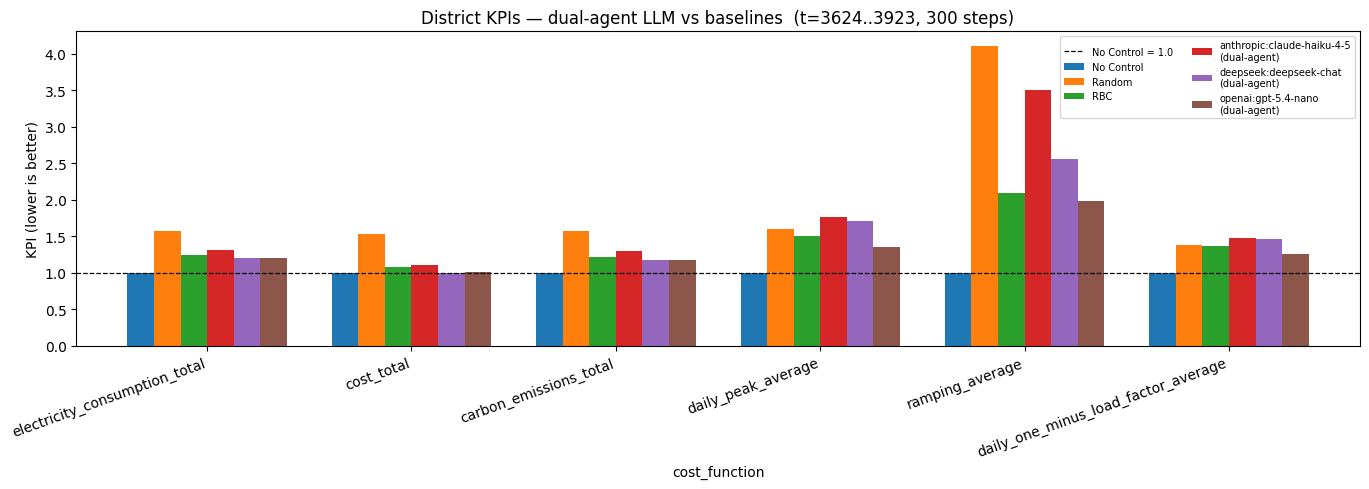

In [23]:
# Bar plot — Challenge KPIs (C, G, R, 1-L) per agent
kpi_cols = ["C  — cost", "G  — carbon", "R  — ramping", "1L — load factor"]
ax = challenge_df[kpi_cols].plot(kind="bar", figsize=(12, 5), width=0.78)
ax.axhline(1.0, color="k", ls="--", lw=0.9, label="No Control = 1.0")
ax.set_ylabel("Ratio to no-control baseline (lower = better)")
ax.set_title(
    f"Challenge KPIs — single-agent LLM vs baselines  "
    f"(t={WEEK_START}..{WEEK_START+WEEK_LEN-1}, {WEEK_LEN} steps)"
)
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## § 14 — Per-Building Breakdown


In [24]:
def per_building_summary(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Per-building action/SoC/reward summary for a single-agent rollout."""
    rows = []
    for b in range(N_BLDGS):
        rows.append({
            "run":           label,
            "building":      f"B{b}",
            "total_reward":  float(df[f"r{b}"].sum()),
            "mean_soc_pct":  float(df[f"soc{b}"].mean() * 100),
            "peak_net_kW":   float(df[f"net{b}"].max()),
            "total_net_kWh": float(df[f"net{b}"].sum()),
            "mean_action":   float(df[f"a{b}"].mean()),
            "std_action":    float(df[f"a{b}"].std()),
        })
    return pd.DataFrame(rows)


if llm_runs:
    per_b = pd.concat([
        per_building_summary(run["df"], name)
        for name, run in llm_runs.items()
    ], ignore_index=True)
    print(f"Per-building breakdown (buildings {BUILDINGS}):")
    display(per_b.set_index(["run", "building"]).round(4))
else:
    print("No LLM runs in llm_runs yet — run provider cells above.")


Per-agent breakdown — α (B0-2) vs β (B3-5)


,buildings,total_reward,mean_soc_pct,peak_net_kW,total_net_kWh,mean_action,std_action
agent,,,,,,,
anthropic / α,"[0, 1, 2]",-1790.8613,71.2261,17.0568,761.7878,0.0401,0.2886
anthropic / β,"[3, 4, 5]",-2565.3952,68.3302,13.1645,1351.1018,0.0352,0.2943
deepseek / α,"[0, 1, 2]",-1503.1538,71.1300,11.8714,726.3495,0.0145,0.1975
deepseek / β,"[3, 4, 5]",-2425.2232,69.5615,14.0271,1316.3913,0.0174,0.2157
openai / α,"[0, 1, 2]",-1498.8720,66.8072,9.7238,740.7209,0.0192,0.1963
openai / β,"[3, 4, 5]",-2253.6308,65.0838,11.8724,1317.5919,0.0127,0.1969


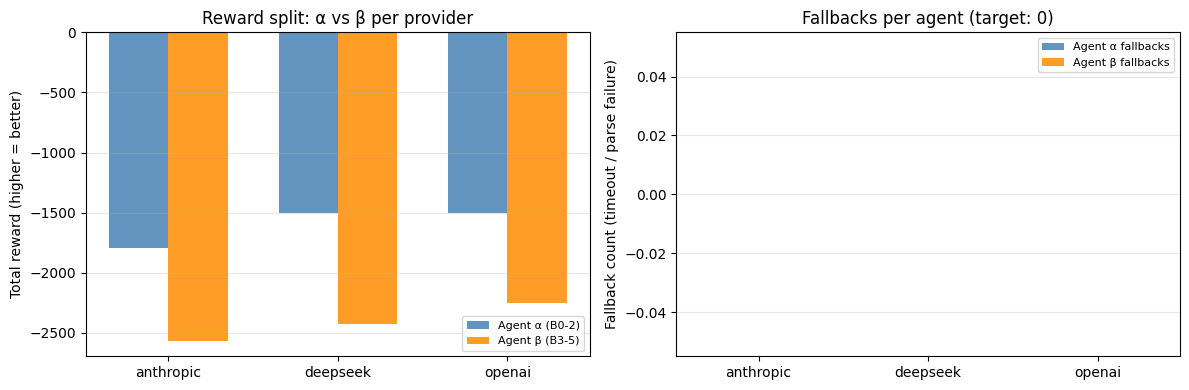

In [25]:
if llm_runs:
    fig, ax = plt.subplots(figsize=(6, 4))
    providers = list(llm_runs.keys())
    rewards   = [llm_runs[n]["df"]["reward_sum"].sum() for n in providers]
    fallbacks = [sum(1 for r in llm_runs[n]["raw_log"] if r["fallback"]) for n in providers]
    x = range(len(providers))
    ax2 = ax.twinx()
    ax.bar(x, rewards, alpha=0.7, color="steelblue", label="Total reward")
    ax2.plot(x, fallbacks, "o-", color="crimson", label="Fallbacks")
    ax.set_xticks(list(x)); ax.set_xticklabels(providers)
    ax.set_ylabel("Total reward (higher = better)", color="steelblue")
    ax2.set_ylabel("Fallback count", color="crimson")
    ax.set_title("Single-agent: reward + fallbacks per provider")
    ax.grid(alpha=0.3, axis="y")
    plt.tight_layout(); plt.show()


## § 15 — Diagnostics

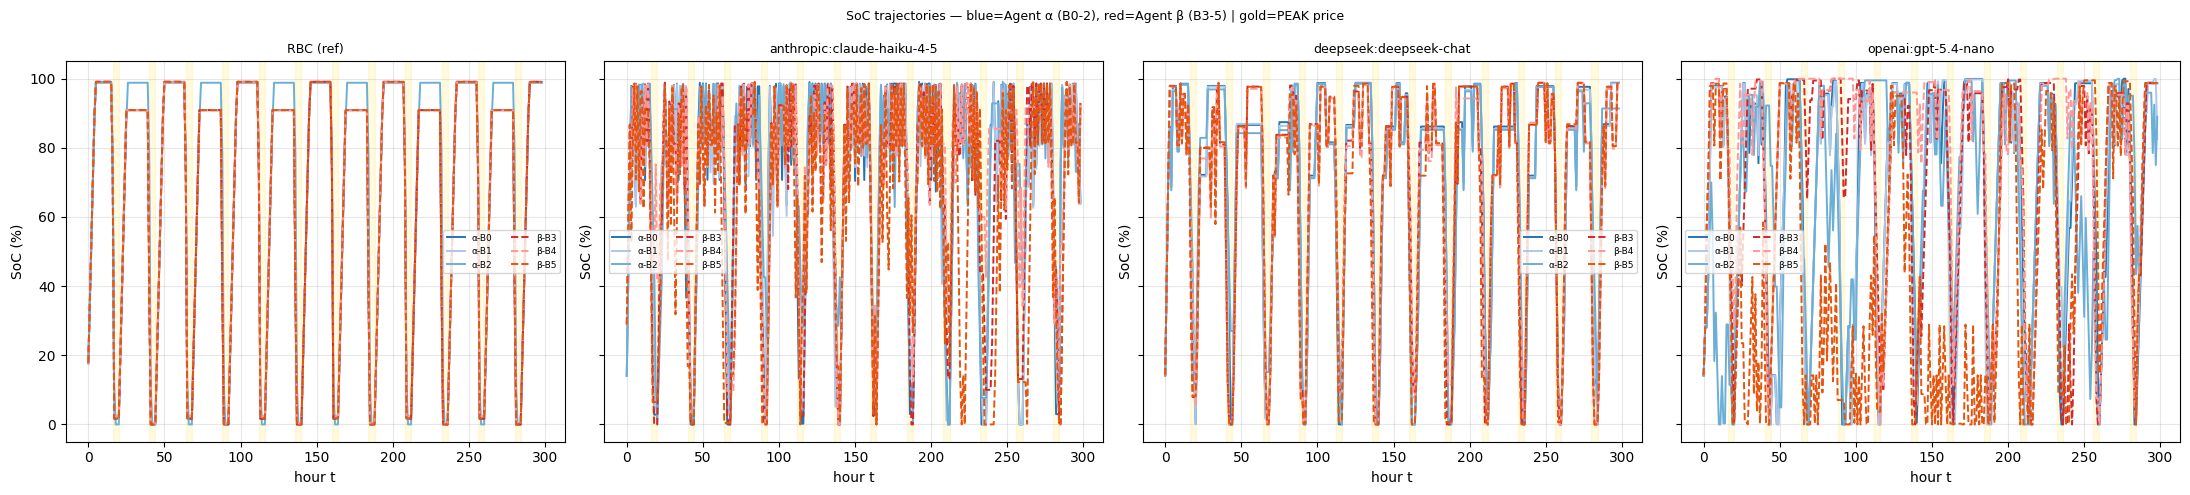

In [26]:
# 15.1  SoC trajectories — one line per building, PEAK price shaded
if not llm_runs:
    print("No LLM runs yet.")
else:
    panels = [(df_rbc, "RBC (ref)")] + [(run["df"], run["label"]) for run in llm_runs.values()]
    fig, axes = plt.subplots(1, len(panels), figsize=(5.5 * len(panels), 5), sharey=True)
    if len(panels) == 1:
        axes = [axes]

    bldg_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

    for ax, (df_, label) in zip(axes, panels):
        for b in range(N_BLDGS):
            ax.plot(df_["t"], df_[f"soc{b}"] * 100,
                    label=f"B{b}", lw=1.4, color=bldg_colors[b % len(bldg_colors)])

        peak_mask = (df_["price"] >= PRICE_PEAK_THRESHOLD).values
        in_peak, span_s = False, 0
        for i_m, is_peak in enumerate(peak_mask):
            if is_peak and not in_peak:
                span_s = i_m; in_peak = True
            elif not is_peak and in_peak:
                ax.axvspan(span_s, i_m - 1, color="gold", alpha=0.12); in_peak = False
        if in_peak:
            ax.axvspan(span_s, len(peak_mask) - 1, color="gold", alpha=0.12)

        ax.set_xlabel("hour t"); ax.set_ylabel("SoC (%)")
        ax.set_title(label, fontsize=9)
        ax.legend(ncol=2, fontsize=7); ax.grid(alpha=0.3)

    plt.suptitle("SoC trajectories — one line per building | gold = PEAK price", fontsize=9)
    plt.tight_layout()
    plt.show()


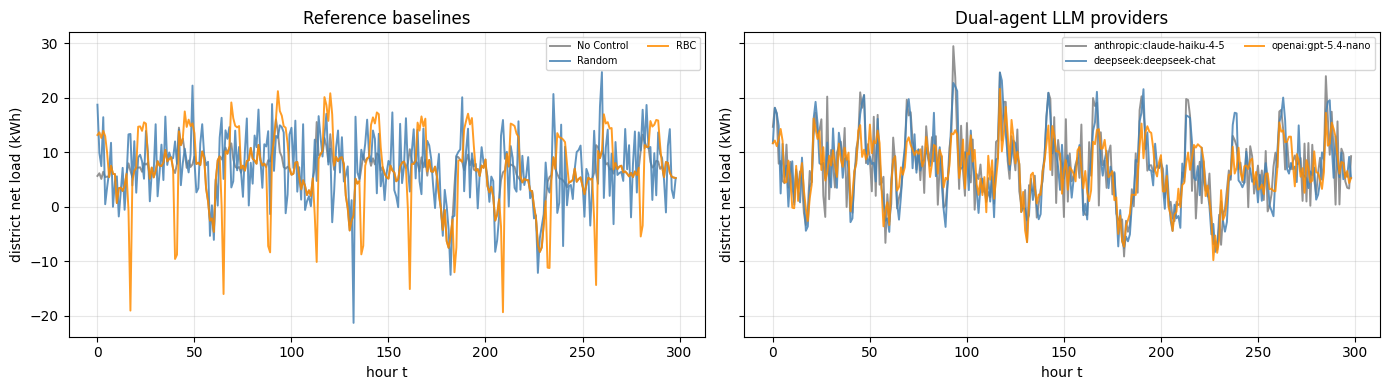

In [27]:
# 15.2  District net load comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

def _plot_net(ax, dfs_labels, title):
    colors = ["gray", "steelblue", "darkorange", "crimson", "forestgreen", "purple"]
    for (df_, lbl), color in zip(dfs_labels, colors):
        net = df_[[f"net{i}" for i in range(N_BLDGS)]].sum(axis=1)
        ax.plot(df_["t"], net, label=lbl, lw=1.4, color=color, alpha=0.85)
    ax.set_xlabel("hour t"); ax.set_ylabel("district net load (kWh)")
    ax.set_title(title); ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

ref_panels = [(df_noop, "No Control"), (df_random, "Random"), (df_rbc, "RBC")]
_plot_net(axes[0], ref_panels, "Reference baselines")

llm_panels = [(run["df"], run["label"]) for run in llm_runs.values()]
if llm_panels:
    _plot_net(axes[1], llm_panels, "Single-agent LLM providers")
else:
    axes[1].text(0.5, 0.5, "No LLM runs yet", ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()


In [28]:
# 15.3  Behavioural summary per provider (rule violations, action stats)
def analyze_run(run: dict) -> dict:
    df       = run["df"]
    raw_log  = run["raw_log"]
    a_cols   = [f"a{i}"   for i in range(N_BLDGS)]
    soc_cols = [f"soc{i}" for i in range(N_BLDGS)]
    A        = df[a_cols].values
    fb       = float(np.mean([r["fallback"] for r in raw_log])) if raw_log else 0.0
    SOC_post = df[soc_cols].values
    SOC_pre  = np.vstack([np.zeros(N_BLDGS), SOC_post[:-1]])
    return {
        "provider":           run["label"],
        "fallback_pct":       round(fb * 100, 1),
        "charge_at_full":     int(((A > 0) & (SOC_pre >= 0.9)).sum()),
        "discharge_at_empty": int(((A < 0) & (SOC_pre <= 0.1)).sum()),
        "mean_action":        round(float(A.mean()), 3),
        "std_action":         round(float(A.std()), 3),
    }


if llm_runs:
    beh_df = pd.DataFrame([analyze_run(run) for run in llm_runs.values()])
    print("Behavioural summary:")
    display(beh_df.set_index("provider").round(3))
    print(
        "\nfallback_pct = timeout + parse failures (target: 0).\n"
        "charge_at_full / discharge_at_empty = prompt-rule violations."
    )


Behavioural summary:


sync_rate_pct  fallback_pct  charge_at_full  \
provider                   agent                                                
anthropic:claude-haiku-4-5 α               46.5           0.0               0   
                           β               53.2           0.0               0   
deepseek:deepseek-chat     α               96.0           0.0               0   
                           β               94.0           0.0               0   
openai:gpt-5.4-nano        α               47.8           0.0              24   
                           β               38.8           0.0              24   

                                  discharge_at_empty  mean_action  std_action  
provider                   agent                                               
anthropic:claude-haiku-4-5 α                       0        0.040       0.289  
                           β                       1        0.035       0.294  
deepseek:deepseek-chat     α                       1        0.014       0.197  
                           β                       4        0.017       0.216  
openai:gpt-5.4-nano        α                      10        0.019       0.196  
                           β                      19        0.013       0.197


Low sync_rate is GOOD (agents act independently → lower demand spikes).
fallback_pct = timeout + parse failures (target: 0).
charge_at_full / discharge_at_empty = prompt-rule violations.


In [29]:
# 15.4  Sample raw responses — 1 timestep per provider
N_SHOW = 1

if not llm_runs:
    print("No LLM runs yet.")
else:
    rng_diag = np.random.default_rng(SEED)
    ref_log  = next(iter(llm_runs.values()))["raw_log"]
    picked   = sorted(rng_diag.choice(len(ref_log), size=min(N_SHOW, len(ref_log)), replace=False).tolist())

    for idx in picked:
        t_val = ref_log[idx]["t"]
        print("=" * 72)
        print(f"t={t_val}")
        for name, run in llm_runs.items():
            entry = run["raw_log"][idx]
            print(f"\n-- {run['label']} --")
            print(f"  State:\n{entry['state_text']}")
            print(f"  Response (fallback={entry['fallback']}):\n{entry['raw']}")
        print()


════════════════════════════════════════════════════════════════════════
t=26

── anthropic:claude-haiku-4-5 ──
  Agent α state:
Month 12, Sat 01:00  |  price=0.210 (LOW)  |  carbon=0.186 (MID)
Forecast:  price+6h=LOW  price+12h=LOW  solar+6h=LOW
Buildings:
  B0: SoC= 98.1%  load=2.63 kWh  last_net=+3.17 kWh  solar=NONE
  B1: SoC= 98.0%  load=1.56 kWh  last_net=+2.48 kWh  solar=NONE
  B2: SoC= 97.5%  load=0.25 kWh  last_net=+2.11 kWh  solar=NONE
  Agent α response (fallback=False):
<thought>
All batteries near full (97-98%), price LOW, no solar. Discharge to serve loads and avoid overcharge waste.
</thought>

<action building=0>DISCHARGE_20</action>
<action building=1>DISCHARGE_20</action>
<action building=2>DISCHARGE_20</action>
  Agent β state:
Month 12, Sat 01:00  |  price=0.210 (LOW)  |  carbon=0.186 (MID)
Forecast:  price+6h=LOW  price+12h=LOW  solar+6h=LOW
Buildings:
  B0: SoC= 98.8%  load=0.65 kWh  last_net=+1.83 kWh  solar=NONE
  B1: SoC= 98.1%  load=1.46 kWh  last_net=+2.48 kW

## § 16 — Save Artifacts

In [ ]:
stamp = time.strftime("%Y%m%d_%H%M%S")

# ── Rollout CSVs ──────────────────────────────────────────────────────────
all_dfs = [df_noop, df_random, df_rbc] + [run["df"] for run in llm_runs.values()]
df_all  = pd.concat(all_dfs, ignore_index=True)
csv_path = ARTIFACTS / f"02_rollouts_{stamp}.csv"
df_all.to_csv(csv_path, index=False)
print(f"Rollout data    : {csv_path}")

# ── KPI tables (Challenge + ZNE via src.eval) ─────────────────────────────
kpi_path = ARTIFACTS / f"02_challenge_{stamp}.csv"
challenge_df.to_csv(kpi_path)
print(f"Challenge table : {kpi_path}")
zne_path = ARTIFACTS / f"02_zne_{stamp}.csv"
zne_df.to_csv(zne_path)
print(f"ZNE table       : {zne_path}")

# ── Per-building summary ──────────────────────────────────────────────────
if llm_runs:
    per_b_path = ARTIFACTS / f"02_per_building_{stamp}.csv"
    per_b.to_csv(per_b_path, index=False)
    print(f"Per-building    : {per_b_path}")

# ── Raw LLM logs (JSON) ───────────────────────────────────────────────────
for name, run in llm_runs.items():
    log_path = ARTIFACTS / f"02_raw_{name}_{stamp}.json"
    with open(log_path, "w") as f:
        json.dump(run["raw_log"], f, indent=2)
    print(f"Raw log {name:10s}: {log_path}")
